In [2]:
import sys
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from api_ingestion import read_json, clean_data_api
from ingestion import *

#get path for dataframes
BASE_DIR = Path().resolve().parent  # if inside analysis folder
DATA_PATH = BASE_DIR / "data" / "Mental_Health_DB.csv"
df = pd.read_csv(DATA_PATH)
df, reject = retrieve_data(df)
df = clean_data(df)
DATA_PATH = BASE_DIR / "data" / "unemployment_data_seed.json"
u_df = read_json(DATA_PATH)
u_df = clean_data_api(u_df)
print(df.dtypes)

indicator                 string[python]
group                     string[python]
state                     string[python]
subgroup                  string[python]
phase                             object
time_period                        int64
time_period_label         string[python]
time_period_start_date    datetime64[ns]
time_period_end_date      datetime64[ns]
value                            float64
lowci                            float64
highci                           float64
confidence_interval       string[python]
quartile_range                    object
dtype: object


In [3]:
df["indicator"].dropna().unique()

<StringArray>
[                                                      'Received Counseling or Therapy, Last 4 Weeks',
                                       'Took Prescription Medication for Mental Health, Last 4 Weeks',
 'Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks',
                                      'Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks']
Length: 4, dtype: string

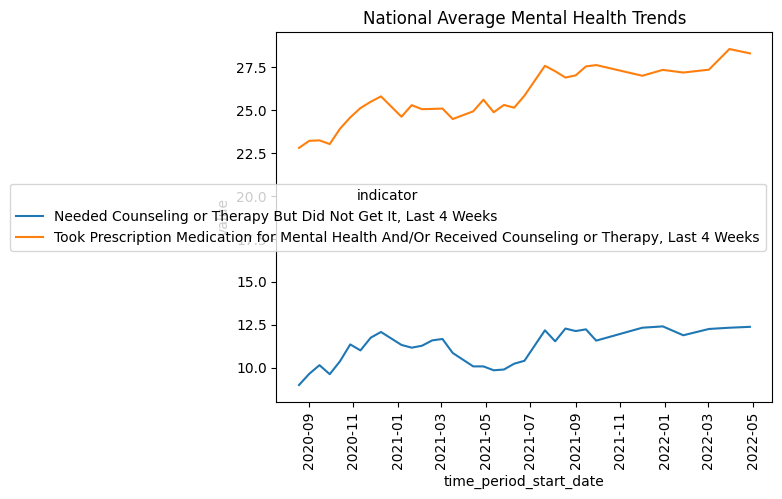

In [4]:
df_useful = df[(df["indicator"] == "Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks") | (df['indicator'] == 'Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks')]
national = (
    df_useful
    .groupby(["time_period_start_date", "indicator"], as_index=False)["value"]
    .mean()
)

plt.figure()
sns.lineplot(
    data=national,
    x="time_period_start_date",
    y="value",
    hue="indicator"
)
plt.xticks(rotation=90)
plt.title("National Average Mental Health Trends")
plt.show()

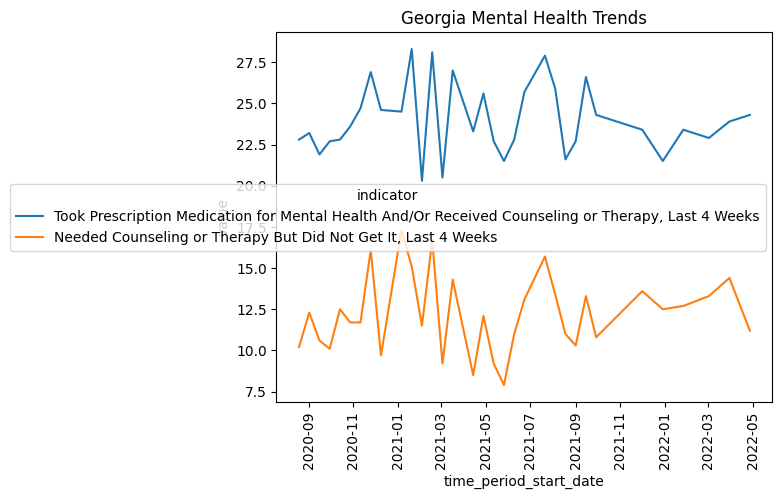

In [5]:
state = "Georgia"

state_df = df_useful[df_useful["state"] == state]

plt.figure()
sns.lineplot(
    data=state_df,
    x="time_period_start_date",
    y="value",
    hue="indicator"
)
plt.xticks(rotation=90)
plt.title(f"{state} Mental Health Trends")
plt.show()

In [6]:
#correlation between unemployment and mental health assistance
if "unemployment_rate" not in u_df.columns and "value" in u_df.columns:
    u_df = u_df.rename(columns={"value": "unemployment_rate"})

# Mental health (CDC)
mh = df_useful.copy()
mh["time_period_start_date"] = pd.to_datetime(mh["time_period_start_date"], errors="coerce")
mh["year"] = mh["time_period_start_date"].dt.year
mh["month"] = mh["time_period_start_date"].dt.month

#separating the mental health database into the 2 usefule indicators one per dataframe
mh_unmet = mh[mh["indicator"] == "Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks"].copy()
mh_treat = mh[mh["indicator"] == "Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks"].copy()


# Unemployment (BLS)
u = u_df.copy()
u["date"] = pd.to_datetime(u["date"], errors="coerce")
u["year"] = u["date"].dt.year
u["month"] = u["date"].dt.month


u_df["unemployment_rate"] = pd.to_numeric(u_df["unemployment_rate"], errors="coerce")

In [7]:

mh_unmet_monthly = (
    mh_unmet.groupby(["state", "indicator", "year", "month"], as_index=False)["value"]
      .mean()
)
mh_treat_monthly = (
    mh_treat.groupby(["state", "indicator", "year", "month"], as_index=False)["value"]
      .mean()
)

u_monthly = (
    u.groupby(["state", "year", "month"], as_index=False)["unemployment_rate"]
      .mean()
)

merged_unmet = mh_unmet_monthly.merge(
    u_monthly,
    on=["state", "year", "month"],
    how="inner"
)
merged_treat = mh_treat_monthly.merge(
    u_monthly,
    on=["state", "year", "month"],
    how="inner"
)


In [8]:
print("unmet information")
print("Rows:", len(merged_unmet))
print(merged_unmet.groupby("state").size().describe())
print(merged_unmet[["value", "unemployment_rate"]].corr(numeric_only=True))

unmet information
Rows: 900
count    50.0
mean     18.0
std       0.0
min      18.0
25%      18.0
50%      18.0
75%      18.0
max      18.0
dtype: float64
                      value  unemployment_rate
value              1.000000          -0.126975
unemployment_rate -0.126975           1.000000


In [9]:
print("treat information")
print("Rows:", len(merged_unmet))
print(merged_unmet.groupby("state").size().describe())
print(merged_unmet[["value", "unemployment_rate"]].corr(numeric_only=True))
print(merged_unmet.columns)

treat information
Rows: 900
count    50.0
mean     18.0
std       0.0
min      18.0
25%      18.0
50%      18.0
75%      18.0
max      18.0
dtype: float64
                      value  unemployment_rate
value              1.000000          -0.126975
unemployment_rate -0.126975           1.000000
Index(['state', 'indicator', 'year', 'month', 'value', 'unemployment_rate'], dtype='object')


            state level_1      corr
6     Connecticut   value -0.759545
47  West Virginia   value -0.744145
43           Utah   value -0.741433
48      Wisconsin   value -0.738850
34           Ohio   value -0.718950
22      Minnesota   value -0.708749
36         Oregon   value -0.706363
33   North Dakota   value -0.697147
31       New York   value -0.690491
24       Missouri   value -0.676044
          state level_1      corr
27       Nevada   value -0.317358
44      Vermont   value -0.281508
7      Delaware   value -0.226747
23  Mississippi   value -0.223763
29   New Jersey   value -0.221005
25      Montana   value -0.204723
17    Louisiana   value -0.189565
49      Wyoming   value -0.127037
9       Georgia   value -0.072985
18        Maine   value  0.263419


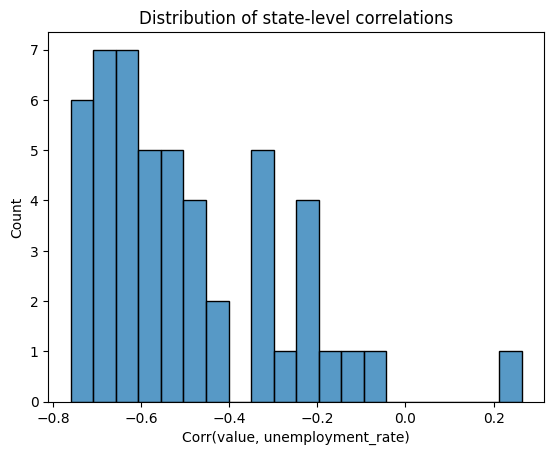

In [10]:
#suprisingly low correlation going to try to figure out why
#looking at it by state treat first
corr_by_state_treat = (
    merged_treat.groupby("state")[["value", "unemployment_rate"]]
          .corr(numeric_only=True)
          .iloc[0::2, -1]   # grab corr(value, unemployment_rate) for each state
          .reset_index()
          .rename(columns={"unemployment_rate": "corr"})
)

corr_by_state_treat = corr_by_state_treat.sort_values("corr")
print(corr_by_state_treat.head(10))
print(corr_by_state_treat.tail(10))

plt.figure()
sns.histplot(corr_by_state_treat["corr"], bins=20)
plt.title("Distribution of state-level correlations")
plt.xlabel("Corr(value, unemployment_rate)")
plt.show()

            state level_1      corr
28  New Hampshire   value -0.715542
3        Arkansas   value -0.693439
1          Alaska   value -0.550391
42          Texas   value -0.549072
10         Hawaii   value -0.480060
15         Kansas   value -0.466209
46     Washington   value -0.458698
16       Kentucky   value -0.450375
35       Oklahoma   value -0.440546
26       Nebraska   value -0.415113
             state level_1      corr
13         Indiana   value -0.064945
34            Ohio   value -0.050549
21        Michigan   value -0.046547
8          Florida   value -0.020163
47   West Virginia   value -0.010103
44         Vermont   value  0.004915
39  South Carolina   value  0.043523
14            Iowa   value  0.075608
32  North Carolina   value  0.220553
5         Colorado   value  0.329491


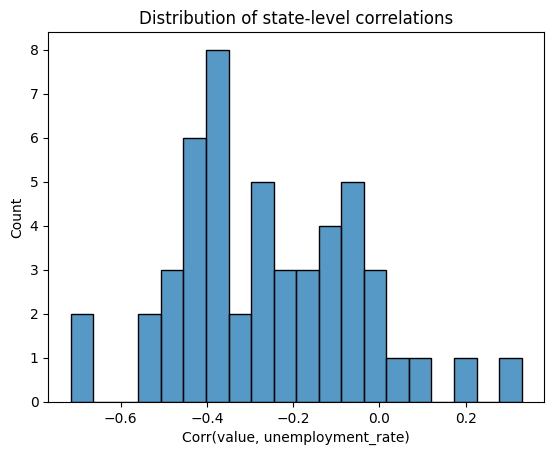

In [11]:
#suprisingly low correlation going to try to figure out why
#looking at it by state here
corr_by_state_unmet = (
    merged_unmet.groupby("state")[["value", "unemployment_rate"]]
          .corr(numeric_only=True)
          .iloc[0::2, -1]   # grab corr(value, unemployment_rate) for each state
          .reset_index()
          .rename(columns={"unemployment_rate": "corr"})
)

corr_by_state_unmet = corr_by_state_unmet.sort_values("corr")
print(corr_by_state_unmet.head(10))
print(corr_by_state_unmet.tail(10))

plt.figure()
sns.histplot(corr_by_state_unmet["corr"], bins=20)
plt.title("Distribution of state-level correlations")
plt.xlabel("Corr(value, unemployment_rate)")
plt.show()

In [12]:
#looking into why unmet had such strong trends. seeing if it is real or a cause of small sample size
tmp_unmet = merged_unmet.sort_values(["state", "year", "month"]).copy()

tmp_unmet["delta_value"] = tmp_unmet.groupby("state")["value"].diff()
tmp_unmet["delta_unemp"] = tmp_unmet.groupby("state")["unemployment_rate"].diff()

def state_corr_diff(df):
    d = df[["delta_value","delta_unemp"]].dropna()
    if len(d) < 5:
        return None
    return d.corr().iloc[0,1]

state_corrs_diff = (
    tmp_unmet.groupby("state")
             .apply(state_corr_diff)
             .reset_index(name="corr_diff")
)

state_corrs_diff.describe()

C:\Users\mishr\AppData\Local\Temp\ipykernel_24356\446375355.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(state_corr_diff)


,corr_diff
count,50.000000
mean,-0.094618
std,0.238365
min,-0.631702
25%,-0.197475
50%,-0.091869
75%,0.039463
max,0.493248


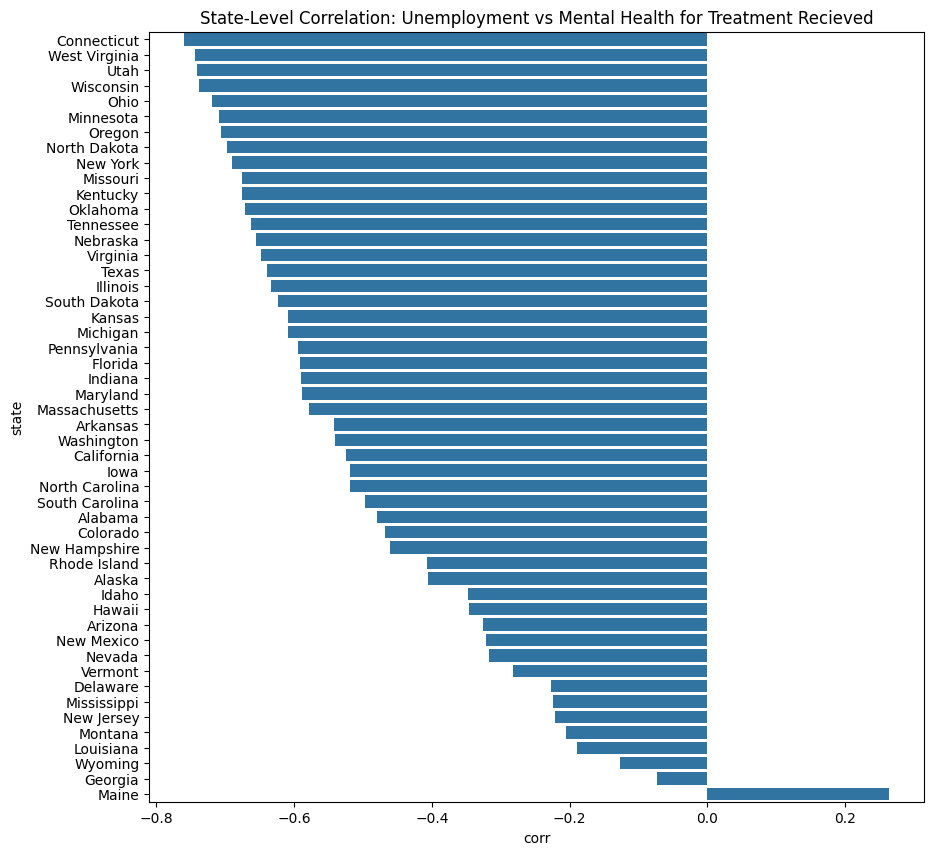

In [31]:
plt.figure(figsize=(10,10))
sns.barplot(data=corr_by_state_treat.sort_values("corr"),
            x="corr",
            y="state")
plt.title("State-Level Correlation: Unemployment vs Mental Health for Treatment Recieved")
plt.show()

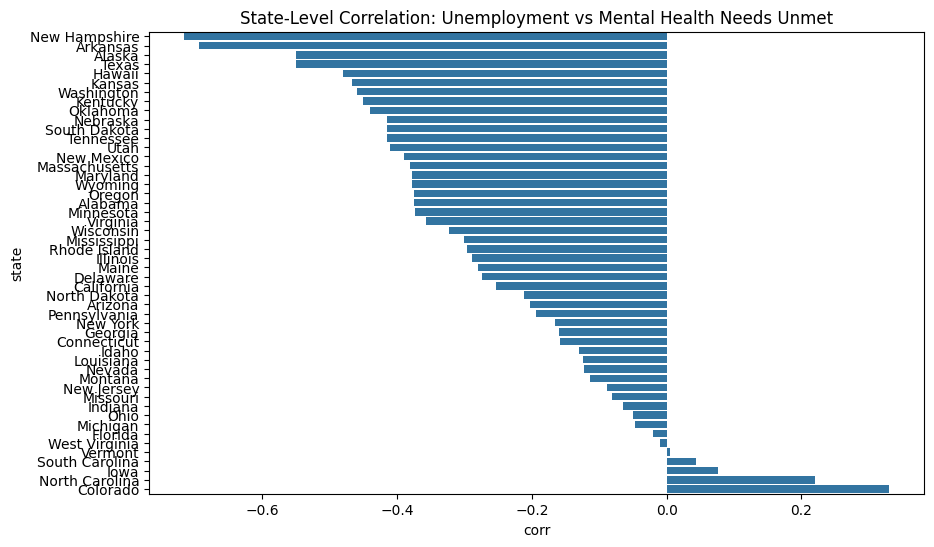

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(data=corr_by_state_unmet.sort_values("corr"),
            x="corr",
            y="state")
plt.title("State-Level Correlation: Unemployment vs Mental Health Needs Unmet")
plt.show()

In [17]:
#checking to see if there is a delay
tmp_treat = merged_treat.sort_values(["state", "month" if "month" in merged_treat.columns else "time_period_start_date"]).copy()

tmp_treat["unemp_lag1"] = tmp_treat.groupby("state")["unemployment_rate"].shift(1)
tmp_treat["unemp_lag2"] = tmp_treat.groupby("state")["unemployment_rate"].shift(2)

print("merged_treat lag check")
print("No lag:", tmp_treat[["value","unemployment_rate"]].corr(numeric_only=True).iloc[0,1])
print("Lag 1:", tmp_treat[["value","unemp_lag1"]].corr(numeric_only=True).iloc[0,1])
print("Lag 2:", tmp_treat[["value","unemp_lag2"]].corr(numeric_only=True).iloc[0,1])

merged_treat lag check
No lag: -0.4601674892531256
Lag 1: -0.18689461181813677
Lag 2: -0.36990160900544006


In [19]:
#checking to see if there is a delay
tmp_umet = merged_unmet.sort_values(["state", "month" if "month" in merged_unmet.columns else "time_period_start_date"]).copy()

tmp_unmet["unemp_lag1"] = tmp_unmet.groupby("state")["unemployment_rate"].shift(1)
tmp_unmet["unemp_lag2"] = tmp_unmet.groupby("state")["unemployment_rate"].shift(2)

print("merged_unmet lag check")
print("No lag:", tmp_unmet[["value","unemployment_rate"]].corr(numeric_only=True).iloc[0,1])
print("Lag 1:", tmp_unmet[["value","unemp_lag1"]].corr(numeric_only=True).iloc[0,1])
print("Lag 2:", tmp_unmet[["value","unemp_lag2"]].corr(numeric_only=True).iloc[0,1])

merged_unmet lag check
No lag: -0.12697536690463893
Lag 1: -0.0733429252951999
Lag 2: -0.05261721251337669


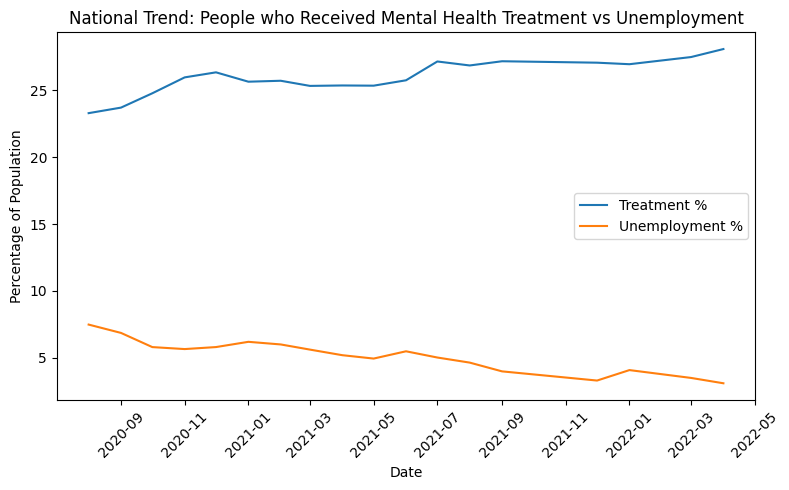

In [34]:
# Build national monthly average
national = (
    merged_treat
    .groupby(["year","month"], as_index=False)[["value","unemployment_rate"]]
    .mean()
)

# Create date column
national["date"] = pd.to_datetime(
    national["year"].astype(str) + "-" + national["month"].astype(str) + "-01"
)

national = national.sort_values("date")

plt.figure(figsize=(8,5))
plt.plot(national["date"], national["value"], label="Treatment %")
plt.plot(national["date"], national["unemployment_rate"], label="Unemployment %")

plt.xlabel("Date")
plt.ylabel("Percentage of Population")
plt.title("National Trend: People who Received Mental Health Treatment vs Unemployment")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

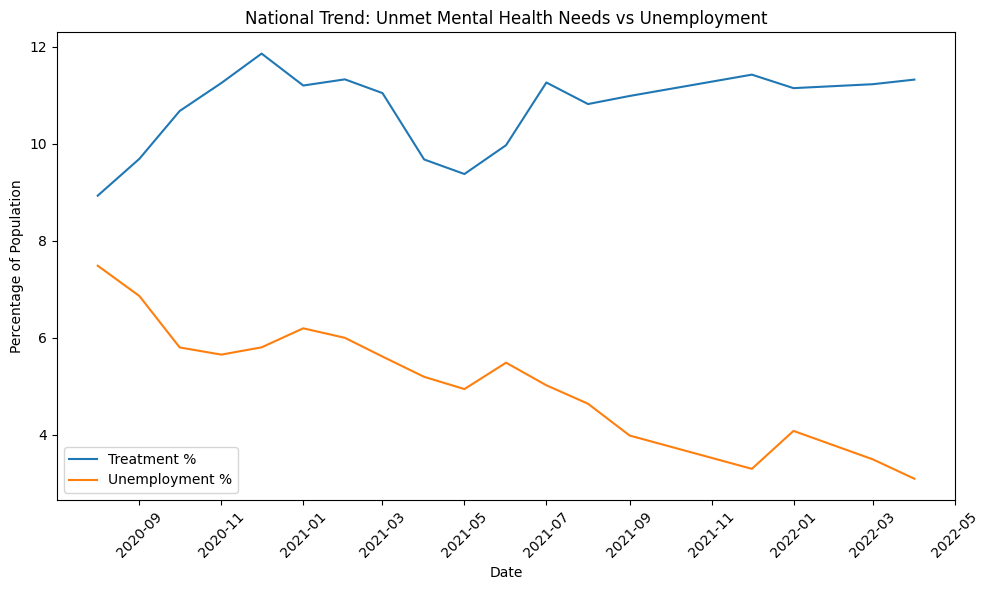

In [27]:
# Build national monthly average
national = (
    merged_unmet
    .groupby(["year","month"], as_index=False)[["value","unemployment_rate"]]
    .mean()
)

# Create date column
national["date"] = pd.to_datetime(
    national["year"].astype(str) + "-" + national["month"].astype(str) + "-01"
)

national = national.sort_values("date")

plt.figure(figsize=(10,6))
plt.plot(national["date"], national["value"], label="Treatment %")
plt.plot(national["date"], national["unemployment_rate"], label="Unemployment %")

plt.xlabel("Date")
plt.ylabel("Percentage of Population")
plt.title("National Trend: Unmet Mental Health Needs vs Unemployment")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

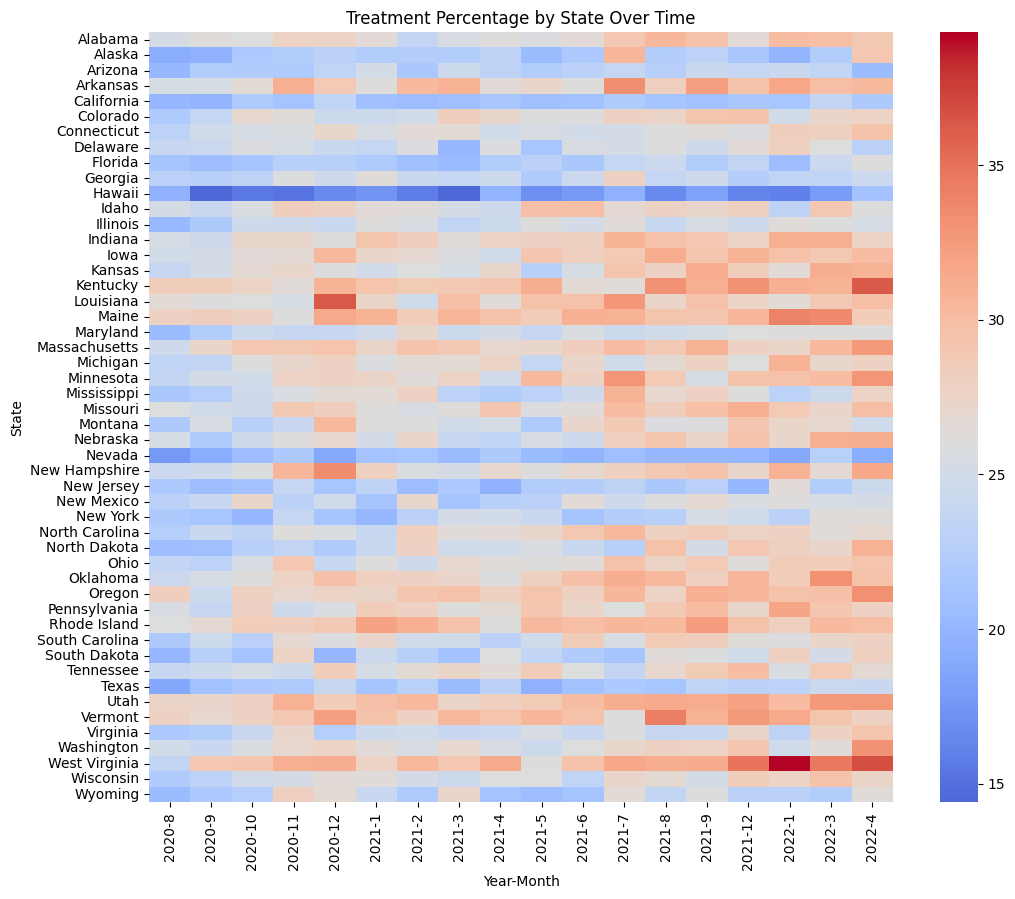

In [28]:
pivot = (
    merged_treat
    .pivot_table(index="state", columns=["year","month"], values="value")
)

plt.figure(figsize=(12,10))
sns.heatmap(pivot, cmap="coolwarm", center=pivot.mean().mean())
plt.title("Treatment Percentage by State Over Time")
plt.xlabel("Year-Month")
plt.ylabel("State")
plt.show()

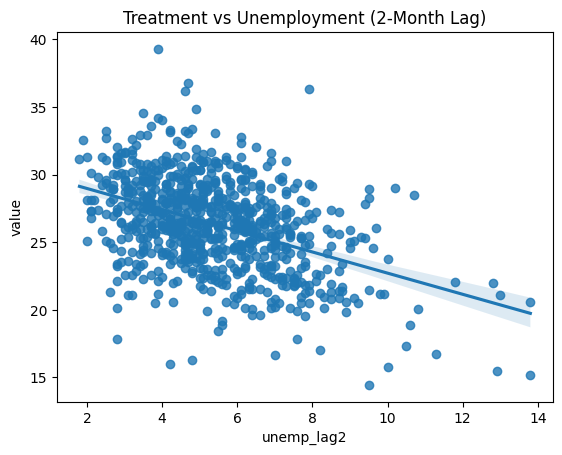

In [29]:
tmp = merged_treat.sort_values(["state","year","month"]).copy()
tmp["unemp_lag2"] = tmp.groupby("state")["unemployment_rate"].shift(2)

sns.regplot(data=tmp, x="unemp_lag2", y="value")
plt.title("Treatment vs Unemployment (2-Month Lag)")
plt.show()

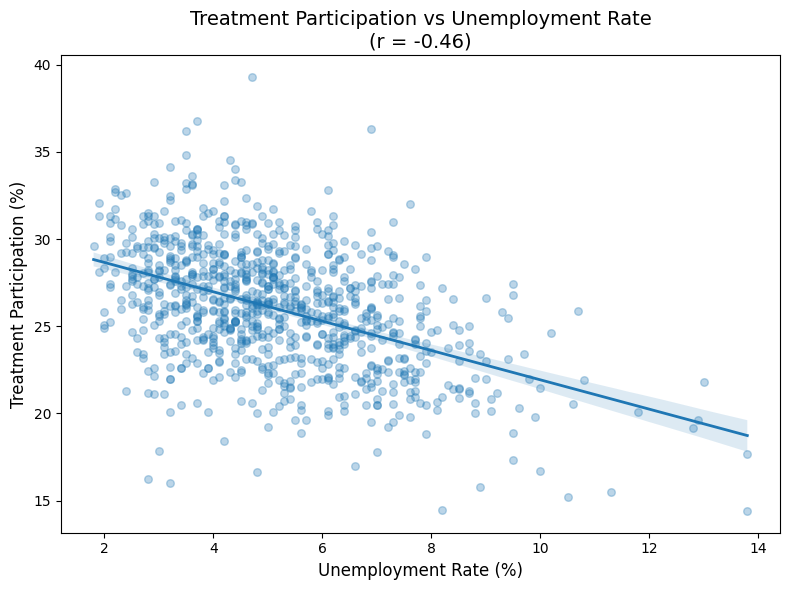

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=merged_treat,
    x="unemployment_rate",
    y="value",
    scatter_kws={"alpha":0.3, "s":30},
    line_kws={"linewidth":2}
)

plt.xlabel("Unemployment Rate (%)", fontsize=12)
plt.ylabel("Received Treatment Participation (%)", fontsize=12)
plt.title("Received Treatment Participation vs Unemployment Rate\n(r = -0.46)", fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
print("Rows no lag:", merged[["value","unemployment_rate"]].dropna().shape[0])
print(tmp[["value","unemp_lag1"]].head())
print(tmp[["value","unemp_lag2"]].head())

Rows no lag: 1800
    value  unemp_lag1
5   12.05         NaN
15  12.40         4.5
23  26.55         3.1
33  30.10         4.5
6   10.10         3.1
    value  unemp_lag2
5   12.05         NaN
15  12.40         NaN
23  26.55         4.5
33  30.10         3.1
6   10.10         4.5


In [ ]:
lag2_corr = (
    tmp.groupby("state")[["value","unemp_lag2"]]
       .corr(numeric_only=True)
       .iloc[0::2, -1]
       .reset_index()
       .rename(columns={"unemp_lag2":"corr_lag2"})
)

print(lag2_corr["corr_lag2"].describe())

count    50.000000
mean     -0.340538
std       0.064487
min      -0.449050
25%      -0.387399
50%      -0.355248
75%      -0.306462
max      -0.150859
Name: corr_lag2, dtype: float64


In [ ]:
plt.figure()
sns.regplot(data=tmp, x="unemp_lag2", y="value", scatter_kws={'alpha':0.3})
plt.title("Mental Health vs Unemployment (2-Month Lag)")
plt.show()

TypeError: regplot() got an unexpected keyword argument 'hue'

<Figure size 640x480 with 0 Axes>

In [ ]:
tmp["indicator"].unique()

<StringArray>
['Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks', 'Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks']
Length: 2, dtype: string

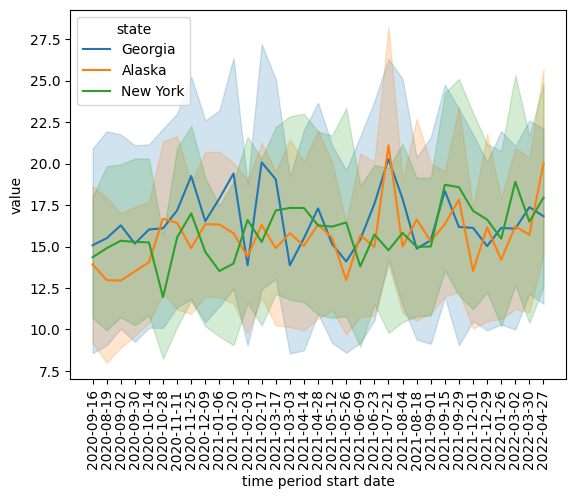

In [ ]:
ex = sns.lineplot(data=df,x='time period start date', y='value', hue= 'state', hue_order=['Georgia', 'Alaska','New York'])
ex.tick_params(axis='x', rotation=90)


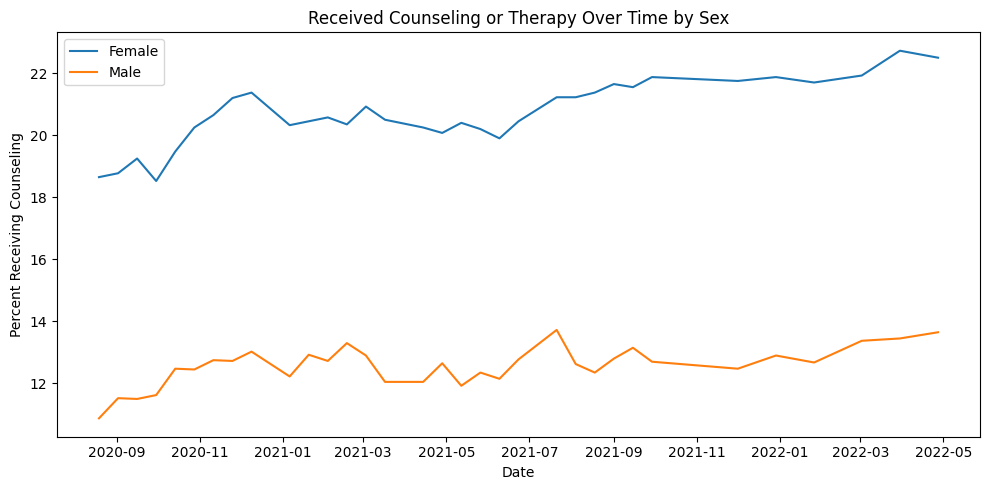

In [ ]:
#did therapy usage increase or decrease over time?(by sex) 

df["time period start date"] = pd.to_datetime(df["time period start date"])

# Filter for sex groups
sex_df = df[df["group"] == "By Sex"]

# Pivot for plotting
pivot = sex_df.pivot_table(index="time period start date",
                      columns="subgroup",
                      values="value",
                      aggfunc="mean")

# Plot
plt.figure(figsize=(10,5))
plt.plot(pivot.index, pivot)
plt.xlabel("Date")
plt.ylabel("Percent Receiving Counseling")
plt.title("Received Counseling or Therapy Over Time by Sex")
plt.legend(pivot.columns)
plt.tight_layout()
plt.show()
